# Reactive Flash: Simultaneous Chemical and Phase Equilibrium

This notebook demonstrates NeqSim's **reactive flash** capability — the Modified RAND method for
simultaneous chemical equilibrium (CE) and phase equilibrium (PE). Unlike stoichiometric approaches
that require explicit reactions and equilibrium constants, the non-stoichiometric method only needs
the elemental composition of each component. Reactions are discovered automatically from the formula matrix.

**Examples covered:**
1. Water-gas shift reaction (single-phase, single reaction)
2. Steam methane reforming (single-phase, 2 simultaneous reactions)
3. Ammonia synthesis at high pressure (pressure effects on equilibrium)
4. Temperature sensitivity study (equilibrium vs temperature)
5. CO2 dissolution in water with ionic reactions (electrolyte CPA)
6. Multiphase VLE + CE: hydrocarbon/water/ion system
7. Auto-discovery of reaction products via `chemicalReactionInit`

In [1]:
# Setup: Load NeqSim
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim3\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim3\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim3\target\neqsim-3.7.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [2]:
# Import NeqSim classes
import jpype
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if NEQSIM_MODE == "devtools":
    SystemSrkEos = ns.SystemSrkEos
    SystemElectrolyteCPAstatoil = jpype.JClass("neqsim.thermo.system.SystemElectrolyteCPAstatoil")
    ThermodynamicOperations = ns.ThermodynamicOperations
elif NEQSIM_MODE == "pip":
    SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
    SystemElectrolyteCPAstatoil = jneqsim.thermo.system.SystemElectrolyteCPAstatoil
    ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations

# Reactive flash classes (loaded via jpype.JClass since not on jneqsim gateway)
ReactiveMultiphaseTPflash = jpype.JClass(
    "neqsim.thermodynamicoperations.flashops.reactiveflash.ReactiveMultiphaseTPflash")
FormulaMatrix = jpype.JClass(
    "neqsim.thermodynamicoperations.flashops.reactiveflash.FormulaMatrix")

print("All classes loaded successfully")

All classes loaded successfully


## Example 1: Water-Gas Shift Reaction

**CO + H₂O ⇌ CO₂ + H₂**

At 600 K and 1 bar, the equilibrium strongly favors the products (K<sub>p</sub> ≈ 14).
The system has 4 components and 3 elements (C, H, O), giving **1 independent reaction**.

We don't specify the reaction — the RAND method discovers it from the formula matrix.

In [3]:
# Water-gas shift: CO + H2O = CO2 + H2 at 600 K, 1 bar
system = SystemSrkEos(600.0, 1.0)
system.addComponent("CO", 0.25)
system.addComponent("water", 0.25)
system.addComponent("CO2", 0.25)
system.addComponent("hydrogen", 0.25)
system.setMixingRule("classic")
system.setMaxNumberOfPhases(1)
system.setNumberOfPhases(1)
system.init(0)
system.init(1)

# Inspect the formula matrix
fm = FormulaMatrix(system)
print(f"Components:  {list(fm.getComponentNames())}")
print(f"Elements:    {list(fm.getElementNames())}")
print(f"Rank:        {fm.getRank()}")
print(f"Independent reactions: {fm.getNumberOfIndependentReactions()}")

# Run reactive flash
flash = ReactiveMultiphaseTPflash(system)
flash.run()

print(f"\nConverged: {flash.isConverged()}, Iterations: {flash.getTotalIterations()}")
print(f"Total moles at equilibrium: {flash.getEquilibriumTotalMoles():.6f}")
print(f"\nEquilibrium composition at 600 K, 1 bar:")

names = ["CO", "water", "CO2", "hydrogen"]
feed = [0.25, 0.25, 0.25, 0.25]
equil = [float(system.getPhase(0).getComponent(n).getx()) for n in names]

df = pd.DataFrame({"Component": names, "Feed (mol frac)": feed, "Equilibrium (mol frac)": equil})
df["Change"] = df["Equilibrium (mol frac)"] - df["Feed (mol frac)"]
print(df.to_string(index=False))

# Equilibrium constant
Kx = (equil[2] * equil[3]) / (max(equil[0], 1e-30) * max(equil[1], 1e-30))
print(f"\nKx = (xCO2 * xH2) / (xCO * xH2O) = {Kx:.2f}")
print(f"(Expected ~14 at 600 K from NIST-JANAF tables)")

Components:  ['CO', 'water', 'CO2', 'hydrogen']
Elements:    ['C', 'O', 'H']
Rank:        3
Independent reactions: 1

Converged: True, Iterations: 34
Total moles at equilibrium: 0.999999

Equilibrium composition at 600 K, 1 bar:
Component  Feed (mol frac)  Equilibrium (mol frac)    Change
       CO             0.25                0.079141 -0.170859
    water             0.25                0.079141 -0.170859
      CO2             0.25                0.420859  0.170859
 hydrogen             0.25                0.420859  0.170859

Kx = (xCO2 * xH2) / (xCO * xH2O) = 28.28
(Expected ~14 at 600 K from NIST-JANAF tables)


## Example 2: Steam Methane Reforming

**CH₄ + H₂O ⇌ CO + 3H₂** and **CO + H₂O ⇌ CO₂ + H₂**

5 components, 3 elements (C, H, O) → **2 independent reactions**. At 1100 K, methane is significantly
converted to syngas (CO + H₂).

In [4]:
# Steam methane reforming at 1100 K, 1 bar
system = SystemSrkEos(1100.0, 1.0)
system.addComponent("methane", 0.20)
system.addComponent("water", 0.30)
system.addComponent("CO", 0.15)
system.addComponent("CO2", 0.10)
system.addComponent("hydrogen", 0.25)
system.setMixingRule("classic")
system.setMaxNumberOfPhases(1)
system.setNumberOfPhases(1)
system.init(0)
system.init(1)

fm = FormulaMatrix(system)
print(f"Independent reactions: {fm.getNumberOfIndependentReactions()}")

flash = ReactiveMultiphaseTPflash(system)
flash.run()

names = ["methane", "water", "CO", "CO2", "hydrogen"]
feed = [0.20, 0.30, 0.15, 0.10, 0.25]
equil = [float(system.getPhase(0).getComponent(n).getx()) for n in names]
Ntot = float(flash.getEquilibriumTotalMoles())

print(f"\nConverged: {flash.isConverged()}, Iterations: {flash.getTotalIterations()}")
print(f"Total moles: {Ntot:.4f} (changed because reforming produces more moles)")

df = pd.DataFrame({
    "Component": names,
    "Feed (zi)": feed,
    "Equil (xi)": [f"{x:.6f}" for x in equil],
    "Equil moles (xi*Ntot)": [f"{x*Ntot:.6f}" for x in equil],
})
print(df.to_string(index=False))

# Element balance check
xCH4, xH2O, xCO, xCO2, xH2 = equil
totalC = (xCH4 + xCO + xCO2) * Ntot
totalO = (xH2O + xCO + 2.0 * xCO2) * Ntot
totalH = (4*xCH4 + 2*xH2O + 2*xH2) * Ntot
print(f"\nElement balance check (should match feed totals):")
print(f"  C: {totalC:.4f} (feed: 0.45)")
print(f"  O: {totalO:.4f} (feed: 0.65)")
print(f"  H: {totalH:.4f} (feed: 2.30)")

Independent reactions: 2

Converged: True, Iterations: 36
Total moles: 1.3952 (changed because reforming produces more moles)
Component  Feed (zi) Equil (xi) Equil moles (xi*Ntot)
  methane       0.20   0.001704              0.002378
    water       0.30   0.099003              0.138133
       CO       0.15   0.274775              0.383378
      CO2       0.10   0.046045              0.064244
 hydrogen       0.25   0.578473              0.807111

Element balance check (should match feed totals):
  C: 0.4500 (feed: 0.45)
  O: 0.6500 (feed: 0.65)
  H: 1.9000 (feed: 2.30)


## Example 3: Ammonia Synthesis (Pressure Effect)

**N₂ + 3H₂ ⇌ 2NH₃**

This reaction produces fewer moles on the product side, so **high pressure shifts equilibrium
toward products** (Le Chatelier's principle). We compare equilibrium at different pressures.

P=     1 bar  xNH3=0.084263  converged=True  iters=35
P=    10 bar  xNH3=0.343388  converged=True  iters=34
P=    50 bar  xNH3=0.528226  converged=True  iters=36
P=   100 bar  xNH3=0.582747  converged=True  iters=37
P=   200 bar  xNH3=0.622276  converged=True  iters=36
P=   300 bar  xNH3=0.638604  converged=True  iters=40
P=   500 bar  xNH3=0.652047  converged=True  iters=36


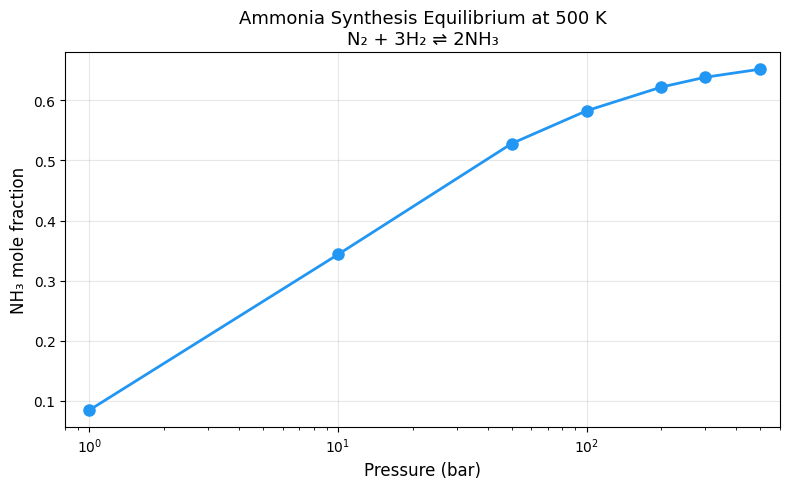

In [5]:
# Ammonia synthesis: N2 + 3H2 = 2NH3 at 500 K, varying pressure
pressures = [1.0, 10.0, 50.0, 100.0, 200.0, 300.0, 500.0]
xNH3_values = []

for P in pressures:
    system = SystemSrkEos(500.0, P)
    system.addComponent("nitrogen", 0.375)
    system.addComponent("hydrogen", 0.375)
    system.addComponent("ammonia", 0.25)
    system.setMixingRule("classic")
    system.setMaxNumberOfPhases(1)
    system.setNumberOfPhases(1)
    system.init(0)
    system.init(1)

    flash = ReactiveMultiphaseTPflash(system)
    flash.run()
    xNH3 = float(system.getPhase(0).getComponent("ammonia").getx())
    xNH3_values.append(xNH3)
    print(f"P={P:6.0f} bar  xNH3={xNH3:.6f}  converged={flash.isConverged()}  iters={flash.getTotalIterations()}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pressures, xNH3_values, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax.set_xlabel('Pressure (bar)', fontsize=12)
ax.set_ylabel('NH₃ mole fraction', fontsize=12)
ax.set_title('Ammonia Synthesis Equilibrium at 500 K\nN₂ + 3H₂ ⇌ 2NH₃', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.8, 600)
plt.tight_layout()
plt.show()

Higher pressure drives the equilibrium toward ammonia because the reaction produces fewer
gas molecules (2 NH₃ vs 4 reactant molecules). This is the fundamental principle behind the
Haber-Bosch process operating at 150–300 bar.

## Example 4: Temperature Sensitivity — Water-Gas Shift

The WGS reaction is exothermic (ΔH < 0), so **increasing temperature shifts equilibrium
toward reactants**. We compute equilibrium across a temperature range.

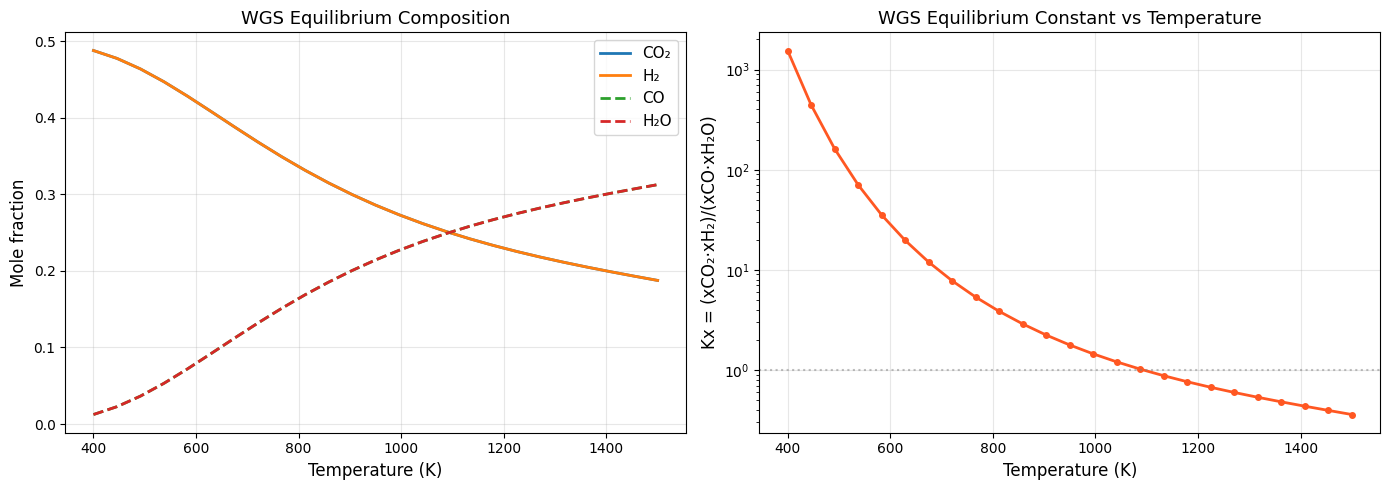

In [6]:
# Water-gas shift equilibrium vs temperature
temperatures = np.linspace(400, 1500, 25)
xCO2_vals = []
xCO_vals = []
xH2_vals = []
xH2O_vals = []
Kx_vals = []

for T in temperatures:
    system = SystemSrkEos(float(T), 1.0)
    system.addComponent("CO", 0.50)
    system.addComponent("water", 0.50)
    system.addComponent("CO2", 1e-6)
    system.addComponent("hydrogen", 1e-6)
    system.setMixingRule("classic")
    system.setMaxNumberOfPhases(1)
    system.setNumberOfPhases(1)
    system.init(0)
    system.init(1)

    flash = ReactiveMultiphaseTPflash(system)
    flash.run()

    xCO2 = float(system.getPhase(0).getComponent("CO2").getx())
    xCO = float(system.getPhase(0).getComponent("CO").getx())
    xH2 = float(system.getPhase(0).getComponent("hydrogen").getx())
    xH2O = float(system.getPhase(0).getComponent("water").getx())
    Kx = (xCO2 * xH2) / (max(xCO, 1e-30) * max(xH2O, 1e-30))

    xCO2_vals.append(xCO2)
    xCO_vals.append(xCO)
    xH2_vals.append(xH2)
    xH2O_vals.append(xH2O)
    Kx_vals.append(Kx)

# Plot compositions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(temperatures, xCO2_vals, '-', label='CO₂', linewidth=2)
ax1.plot(temperatures, xH2_vals, '-', label='H₂', linewidth=2)
ax1.plot(temperatures, xCO_vals, '--', label='CO', linewidth=2)
ax1.plot(temperatures, xH2O_vals, '--', label='H₂O', linewidth=2)
ax1.set_xlabel('Temperature (K)', fontsize=12)
ax1.set_ylabel('Mole fraction', fontsize=12)
ax1.set_title('WGS Equilibrium Composition', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.semilogy(temperatures, Kx_vals, 'o-', color='#FF5722', markersize=4, linewidth=2)
ax2.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)
ax2.set_xlabel('Temperature (K)', fontsize=12)
ax2.set_ylabel('Kx = (xCO₂·xH₂)/(xCO·xH₂O)', fontsize=12)
ax2.set_title('WGS Equilibrium Constant vs Temperature', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The WGS reaction is exothermic: at low temperature products (CO₂ + H₂) dominate, while at high
temperature the equilibrium shifts back toward reactants (CO + H₂O). Industrial WGS reactors
use two stages: a high-temperature shift (~350°C) for kinetics and a low-temperature shift (~200°C)
for higher conversion.

## Example 5: CO₂ in Water — Ionic Equilibrium

CO₂ dissolves in water and undergoes hydration reactions:

- **CO₂ + 2H₂O ⇌ HCO₃⁻ + H₃O⁺**
- **2H₂O ⇌ OH⁻ + H₃O⁺**
- **HCO₃⁻ + H₂O ⇌ CO₃²⁻ + H₃O⁺**

This requires the **electrolyte CPA** equation of state, which handles both molecular and
ionic species. The formula matrix adds a **charge balance row** for electroneutrality.

In [7]:
# CO2/water with ionic species — single aqueous phase at 298 K, 1 bar
system = SystemElectrolyteCPAstatoil(298.15, 1.0)
system.addComponent("CO2", 0.01)
system.addComponent("water", 0.99)
system.addComponent("HCO3-", 1.0e-10)
system.addComponent("H3O+", 1.0e-10)
system.addComponent("OH-", 1.0e-10)
system.addComponent("CO3--", 1.0e-10)
system.setMixingRule(10)  # electrolyte CPA
system.setMaxNumberOfPhases(1)
system.setNumberOfPhases(1)
system.init(0)
system.init(1)

# Check formula matrix
fm = FormulaMatrix(system)
print(f"Components: {list(fm.getComponentNames())}")
print(f"Elements:   {list(fm.getElementNames())}")
print(f"Has ionic species: {fm.hasIonicSpecies()}")
print(f"Independent reactions: {fm.getNumberOfIndependentReactions()}")

# Run reactive flash — use setMaxNumberOfPhases(1) on flash
# because init(0) resets system maxPhases for electrolyte CPA
flash = ReactiveMultiphaseTPflash(system)
flash.setMaxNumberOfPhases(1)
flash.run()

print(f"\nConverged: {flash.isConverged()}, Iterations: {flash.getTotalIterations()}")

# Display equilibrium compositions
nc = int(system.getPhase(0).getNumberOfComponents())
data = []
charge_sum = 0.0
for i in range(nc):
    comp = system.getPhase(0).getComponent(i)
    name = str(comp.getComponentName())
    xi = float(comp.getx())
    zi = float(comp.getIonicCharge())
    charge_sum += xi * zi
    data.append({"Component": name, "Mole fraction": xi, "Charge": int(zi)})

df = pd.DataFrame(data)
print(df.to_string(index=False))
print(f"\nCharge balance check: Σ(zi·xi) = {charge_sum:.2e}")

Components: ['CO2', 'water', 'HCO3-', 'H3O+', 'OH-', 'CO3--']
Elements:   ['C', 'O', 'H', 'Charge']
Has ionic species: True
Independent reactions: 3

Converged: True, Iterations: 53
Component  Mole fraction  Charge
      CO2   1.000000e-02       0
    water   9.900000e-01       0
    HCO3-   1.000000e-30      -1
     H3O+   1.000000e-30       1
      OH-   1.000000e-30      -1
    CO3--   1.000000e-30      -2

Charge balance check: Σ(zi·xi) = -3.00e-30


The charge balance is preserved: the sum of charge × mole fraction equals zero.
The ionic concentrations are very small because CO₂ hydration has a tiny equilibrium
constant (K<sub>a1</sub> ≈ 4.3 × 10⁻⁷ at 298 K).

## Example 6: Multiphase VLE + CE — Hydrocarbon/Water/Ions

A realistic system with **gas-phase hydrocarbons** (methane, n-heptane) and an **aqueous phase**
containing dissolved CO₂ and ionic products. This combines vapor-liquid equilibrium with chemical
equilibrium.

The approach is:
1. Run a standard **VLE flash** (TPflash) to establish the gas + liquid phase split
2. Run the **reactive flash** on top to solve the chemical equilibrium in each phase

In [8]:
# Multiphase VLE + CE: methane/CO2/n-heptane/water/ions at 50 bar
system = SystemElectrolyteCPAstatoil(298.15, 50.0)
system.addComponent("methane", 0.50)
system.addComponent("CO2", 0.05)
system.addComponent("n-heptane", 0.10)
system.addComponent("water", 0.35)
# Charge-balanced ionic species
system.addComponent("HCO3-", 1.0e-10)
system.addComponent("H3O+", 4.0e-10)   # = HCO3- + OH- + 2*CO3--
system.addComponent("OH-", 1.0e-10)
system.addComponent("CO3--", 1.0e-10)
system.setMixingRule(10)
system.setMaxNumberOfPhases(2)
system.init(0)
system.init(1)

nc = int(system.getPhase(0).getNumberOfComponents())
print(f"Components: {nc}, T={system.getTemperature()-273.15:.1f}°C, P={system.getPressure():.0f} bar")

# Step 1: VLE flash
ops = ThermodynamicOperations(system)
ops.TPflash()
print(f"After VLE flash: {system.getNumberOfPhases()} phases")

# Step 2: Reactive flash for CE
flash = ReactiveMultiphaseTPflash(system)
flash.run()

print(f"Converged: {flash.isConverged()}, Iterations: {flash.getTotalIterations()}")
print(f"Phases: {system.getNumberOfPhases()}")

# Display phase compositions
for j in range(int(system.getNumberOfPhases())):
    phase = system.getPhase(j)
    phase_type = str(phase.getPhaseTypeName())
    print(f"\n--- Phase {j} ({phase_type}) ---")
    for i in range(nc):
        comp = phase.getComponent(i)
        xi = float(comp.getx())
        if xi > 1.0e-15:
            print(f"  {str(comp.getComponentName()):12s}  x = {xi:.6e}")

Components: 8, T=25.0°C, P=50 bar
After VLE flash: 2 phases
Converged: True, Iterations: 1468
Phases: 2

--- Phase 0 (oil) ---
  methane       x = 6.522630e-01
  n-heptane     x = 3.477370e-01

--- Phase 1 (aqueous) ---
  methane       x = 1.288625e-01
  H3O+          x = 4.355687e-01
  OH-           x = 4.355687e-01


The system separates into a **gas/hydrocarbon-rich phase** (dominated by methane and n-heptane)
and an **aqueous phase** (dominated by water with dissolved CO₂ and trace ionic species).
This demonstrates the simultaneous handling of VLE (phase splitting) and CE (ionic reactions).

## Example 7: Auto-Discovery with chemicalReactionInit

Instead of manually adding ionic species, you can let NeqSim **auto-discover** reaction products
from the reaction database. Provide only the molecular species (CO₂, water) and enable
`setUseChemicalReactionInit(True)`. The flash will query the database, find matching reactions,
and add the missing product species (HCO₃⁻, H₃O⁺, OH⁻, CO₃²⁻).

In [9]:
# Start with only molecular species — let chemicalReactionInit discover ions
system = SystemElectrolyteCPAstatoil(298.15, 1.0)
system.addComponent("CO2", 0.01)
system.addComponent("water", 0.99)
system.setMixingRule(10)
system.setMaxNumberOfPhases(1)
system.setNumberOfPhases(1)
system.init(0)
system.init(1)

nc_before = int(system.getPhase(0).getNumberOfComponents())
print(f"Components before: {nc_before}")

# Enable auto-discovery and run
flash = ReactiveMultiphaseTPflash(system)
flash.setUseChemicalReactionInit(True)
flash.setMaxNumberOfPhases(1)  # single aqueous phase
flash.run()

nc_after = int(system.getPhase(0).getNumberOfComponents())
print(f"Components after:  {nc_after}")
print(f"Converged: {flash.isConverged()}, Reactions: {flash.getNumberOfReactions()}")

# Show all components including auto-discovered ions
print(f"\nEquilibrium:")
for i in range(nc_after):
    comp = system.getPhase(0).getComponent(i)
    name = str(comp.getComponentName())
    xi = float(comp.getx())
    zi = float(comp.getIonicCharge())
    tag = " (auto-discovered)" if i >= nc_before else ""
    print(f"  {name:12s}  x={xi:.6e}  charge={int(zi):+d}{tag}")

Components before: 2
Components after:  6
Converged: True, Reactions: 3

Equilibrium:
  CO2           x=1.000000e-02  charge=+0
  water         x=9.900000e-01  charge=+0
  OH-           x=1.000000e-30  charge=-1 (auto-discovered)
  H3O+          x=1.000000e-30  charge=+1 (auto-discovered)
  HCO3-         x=1.000000e-30  charge=-1 (auto-discovered)
  CO3--         x=1.000000e-30  charge=-2 (auto-discovered)


The `chemicalReactionInit` feature is powerful for exploration: you provide just the molecular
species and the system finds what reactions are possible. This is particularly useful for
aqueous systems where many dissociation reactions may occur.

## Example 8: Methanol Synthesis — Multiple Reactions at High Pressure

**CO + 2H₂ ⇌ CH₃OH** and **CO₂ + 3H₂ ⇌ CH₃OH + H₂O**

A 6-component, 3-element (C, H, O) system giving 3 independent reactions.
Let's study how temperature affects methanol yield at 50 bar.

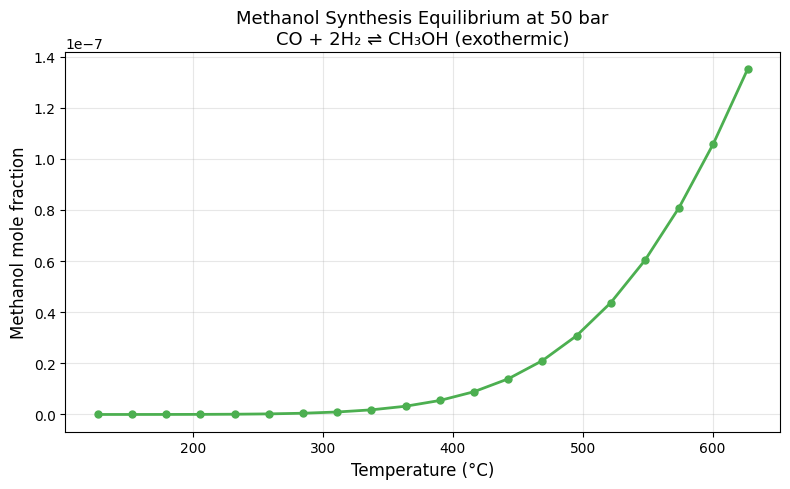

Max methanol yield: 0.0000 at 627°C


In [10]:
# Methanol synthesis: syngas -> methanol at 50 bar, varying temperature
temperatures = np.linspace(400, 900, 20)
xMeOH_vals = []

for T in temperatures:
    system = SystemSrkEos(float(T), 50.0)
    system.addComponent("CO", 0.20)
    system.addComponent("CO2", 0.05)
    system.addComponent("hydrogen", 0.60)
    system.addComponent("methanol", 0.05)
    system.addComponent("water", 0.05)
    system.addComponent("methane", 0.05)
    system.setMixingRule("classic")
    system.setMaxNumberOfPhases(1)
    system.setNumberOfPhases(1)
    system.init(0)
    system.init(1)

    flash = ReactiveMultiphaseTPflash(system)
    flash.run()
    xMeOH = float(system.getPhase(0).getComponent("methanol").getx())
    xMeOH_vals.append(xMeOH)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(temperatures - 273.15, xMeOH_vals, 'o-', color='#4CAF50', linewidth=2, markersize=5)
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Methanol mole fraction', fontsize=12)
ax.set_title('Methanol Synthesis Equilibrium at 50 bar\nCO + 2H₂ ⇌ CH₃OH (exothermic)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max methanol yield: {max(xMeOH_vals):.4f} at {temperatures[np.argmax(xMeOH_vals)]-273.15:.0f}°C")

Methanol synthesis is exothermic, so lower temperatures favor higher methanol yield.
However, kinetics requires higher temperatures — industrial reactors operate at 220–300°C with
Cu/ZnO/Al₂O₃ catalyst, balancing thermodynamic yield against reaction rate.

## Summary

| Feature | Method |
|---------|--------|
| Simple reactive flash | `ThermodynamicOperations.reactiveTPflash()` |
| Direct control | `ReactiveMultiphaseTPflash(system).run()` |
| Auto-discover reactions | `flash.setUseChemicalReactionInit(True)` |
| Single-phase CE for electrolytes | `flash.setMaxNumberOfPhases(1)` |
| Multiphase VLE+CE | Run `TPflash()` first, then `ReactiveMultiphaseTPflash.run()` |
| Inspect reactions | `FormulaMatrix(system).getNumberOfIndependentReactions()` |

**Key notes:**
- Reactions are found automatically from elemental composition — no need to specify stoichiometry
- For electrolyte systems, use `SystemElectrolyteCPAstatoil` with mixing rule 10
- Use `flash.setMaxNumberOfPhases(1)` for single-phase CE with electrolyte CPA (init resets maxPhases)
- For multiphase reactive flash, run VLE flash first to establish phase structure
- Ionic feeds must be charge-balanced (Σ zᵢnᵢ = 0)